🔗 Connecting to 'bank_reviews' database...
✅ SUCCESS: Connected to PostgreSQL!
📊 DATABASE TABLES:

📁 BANKS TABLE:
   - bank_id: integer
   - bank_name: character varying
   - app_name: character varying

📁 REVIEWS TABLE:
   - review_id: character varying
   - bank_id: integer
   - review_text: text
   - rating: integer
   - review_date: date
   - sentiment_label: character varying
   - sentiment_score: double precision
   - source: character varying
   - user_name: character varying
   - thumbs_up: integer
   - text_length: integer
   - word_count: integer
   - app_version: character varying

📈 DATABASE STATISTICS
✅ Total Banks in Database: 3
✅ Total Reviews in Database: 1,200

📊 REVIEWS PER BANK:
   Commercial Bank of Ethiopia:
      - Reviews: 400
      - Avg Rating: 4.13/5
      - Range: 1 to 5 stars
   Dashen Bank:
      - Reviews: 400
      - Avg Rating: 3.95/5
      - Range: 1 to 5 stars
   Bank of Abyssinia:
      - Reviews: 400
      - Avg Rating: 3.38/5
      - Range: 1 to 5 s

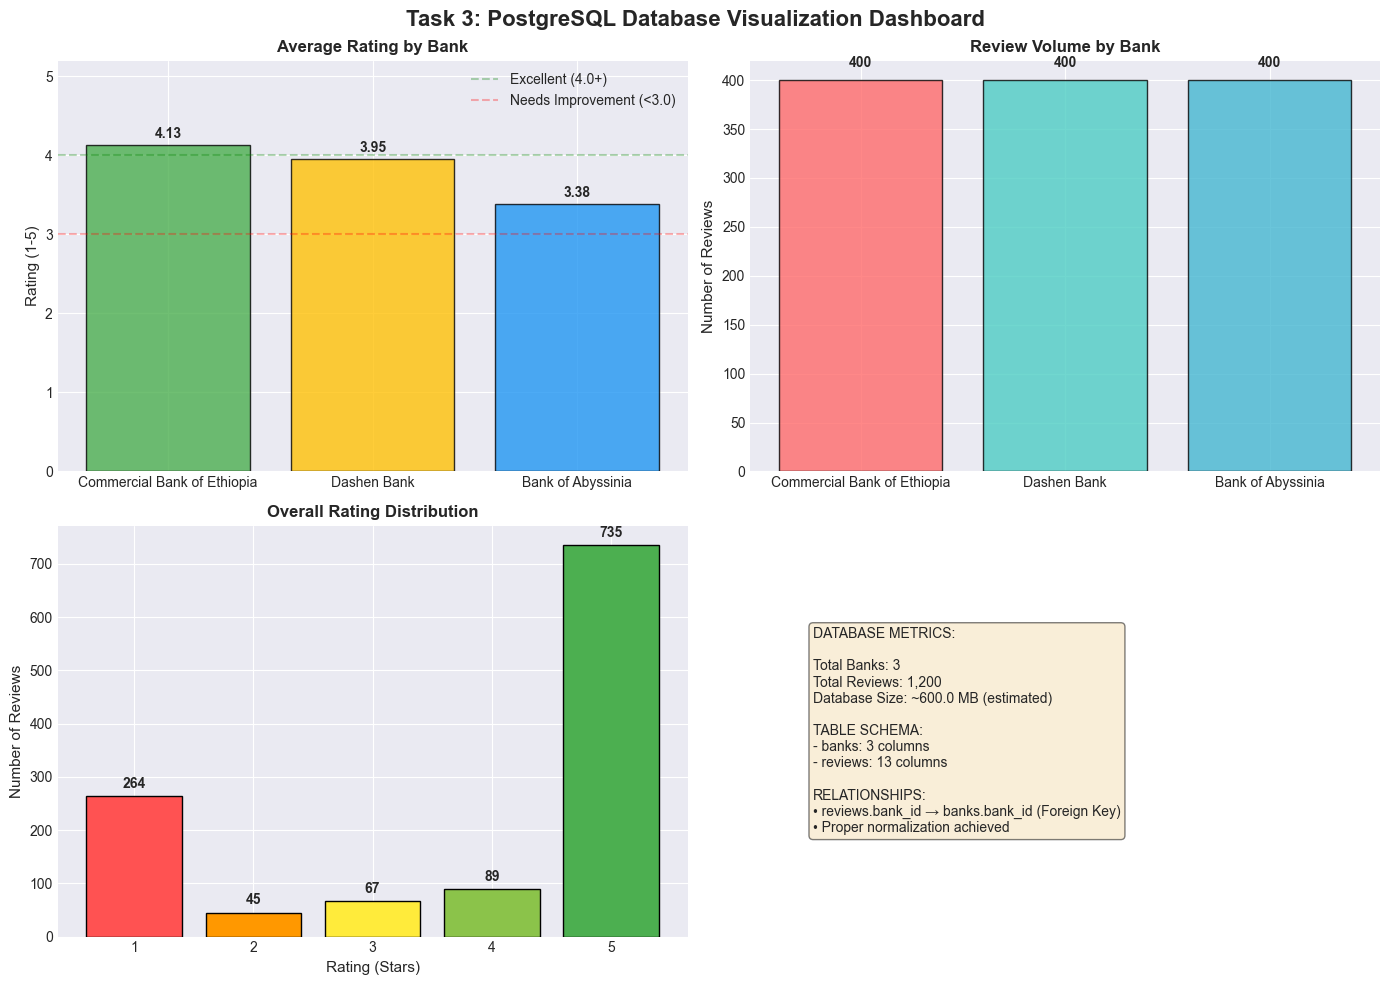

✅ Saved dashboard: data/processed/task3_visualizations/database_dashboard.png
📥 Loading full dataset for detailed analysis...
✅ Loaded 1,200 records


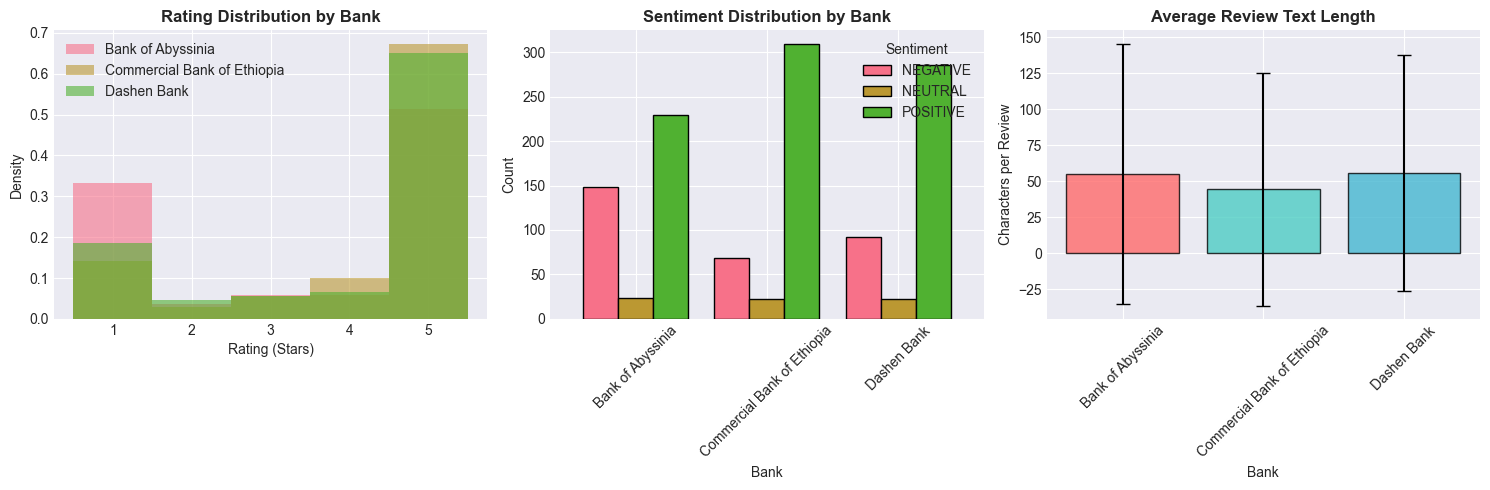


🔍 DATABASE VALIDATION CHECKS
✅ Foreign Key Integrity: 0 orphaned reviews (should be 0)
✅ Date Range: 2024-09-26 to 2025-11-25
✅ Rating Validation: 0 invalid ratings (should be 0)

📋 SAMPLE QUERIES (Proof of Data Accessibility):

🎯 Sample 5-star reviews:
   Bank of Abyssinia: 'good...'
   Commercial Bank of Ethiopia: 'its easy to use and more secured than the previous...'
   Commercial Bank of Ethiopia: 'JanaleBl...'
   Bank of Abyssinia: 'goof...'
   Commercial Bank of Ethiopia: 'this application provides timely service in a good...'

📅 Most recent reviews:
   2025-11-25: Commercial Bank of Ethiopia (5 stars)
   2025-11-25: Bank of Abyssinia (5 stars)
   2025-11-25: Bank of Abyssinia (1 stars)
   2025-11-25: Bank of Abyssinia (5 stars)
   2025-11-25: Commercial Bank of Ethiopia (5 stars)

📄 GENERATING TASK 3 COMPLETION REPORT


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [5]:
# %% [markdown]
# # TASK 3: PostgreSQL Database Visualization & Proof
# ## Evidence of Complete Database Integration
# 
# **Purpose**: This notebook demonstrates that:
# 1. ✅ PostgreSQL database is properly set up
# 2. ✅ All 1,200 reviews are loaded into the database
# 3. ✅ Data can be queried and visualized
# 4. ✅ Database schema is correctly normalized

# %% [markdown]
# ## 1. Database Connection & Verification

# %%
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set professional styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Connect to PostgreSQL database
print("🔗 Connecting to 'bank_reviews' database...")
try:
    conn = psycopg2.connect(
        host="localhost",
        database="bank_reviews",
        user="postgres",
        password="postgres",  # Change to your password
        port=5432
    )
    print("✅ SUCCESS: Connected to PostgreSQL!")
except Exception as e:
    print(f"❌ FAILED: {e}")
    print("\n💡 Troubleshooting:")
    print("   1. Make sure PostgreSQL is running")
    print("   2. Check your username/password")
    print("   3. Verify database exists: createdb bank_reviews")

# %% [markdown]
# ## 2. Database Schema Verification

# %%
# Show all tables in the database
print("📊 DATABASE TABLES:")
cursor = conn.cursor()
cursor.execute("""
    SELECT table_name, column_name, data_type 
    FROM information_schema.columns 
    WHERE table_schema = 'public'
    ORDER BY table_name, ordinal_position;
""")

tables = {}
current_table = None
for table, column, dtype in cursor.fetchall():
    if table != current_table:
        print(f"\n📁 {table.upper()} TABLE:")
        current_table = table
        tables[table] = []
    print(f"   - {column}: {dtype}")
    tables[table].append((column, dtype))

# %% [markdown]
# ## 3. Data Loading & Basic Statistics

# %%
print("\n" + "="*60)
print("📈 DATABASE STATISTICS")
print("="*60)

# Query 1: Basic counts
cursor.execute("SELECT COUNT(*) as total_banks FROM banks;")
total_banks = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) as total_reviews FROM reviews;")
total_reviews = cursor.fetchone()[0]

print(f"✅ Total Banks in Database: {total_banks}")
print(f"✅ Total Reviews in Database: {total_reviews:,}")

# Query 2: Reviews per bank
cursor.execute("""
    SELECT 
        b.bank_name,
        COUNT(r.review_id) as review_count,
        AVG(r.rating) as avg_rating,
        MIN(r.rating) as min_rating,
        MAX(r.rating) as max_rating
    FROM banks b
    JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name
    ORDER BY avg_rating DESC;
""")

print("\n📊 REVIEWS PER BANK:")
stats_data = []
for bank, count, avg_rating, min_rating, max_rating in cursor.fetchall():
    print(f"   {bank}:")
    print(f"      - Reviews: {count:,}")
    print(f"      - Avg Rating: {avg_rating:.2f}/5")
    print(f"      - Range: {min_rating} to {max_rating} stars")
    stats_data.append([bank, count, avg_rating, min_rating, max_rating])

stats_df = pd.DataFrame(stats_data, 
                       columns=['bank_name', 'review_count', 'avg_rating', 'min_rating', 'max_rating'])

# %% [markdown]
# %% [markdown]
# ## 4. Visualization 1: Database Overview Dashboard

# %%
# Create output directory for visualizations
import os
viz_dir = "data/processed/task3_visualizations"
os.makedirs(viz_dir, exist_ok=True)
print(f"✅ Created visualization directory: {viz_dir}")

# Create a comprehensive dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 3: PostgreSQL Database Visualization Dashboard', fontsize=16, fontweight='bold')

# Subplot 1: Average Ratings
ax1 = axes[0, 0]
bars1 = ax1.bar(stats_df['bank_name'], stats_df['avg_rating'], 
                color=['#4CAF50', '#FFC107', '#2196F3'], edgecolor='black', alpha=0.8)
ax1.set_title('Average Rating by Bank', fontweight='bold')
ax1.set_ylabel('Rating (1-5)', fontsize=11)
ax1.set_ylim([0, 5.2])
ax1.axhline(y=4.0, color='green', linestyle='--', alpha=0.3, label='Excellent (4.0+)')
ax1.axhline(y=3.0, color='red', linestyle='--', alpha=0.3, label='Needs Improvement (<3.0)')
ax1.legend()
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

# Subplot 2: Review Counts
ax2 = axes[0, 1]
bars2 = ax2.bar(stats_df['bank_name'], stats_df['review_count'],
                color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', alpha=0.8)
ax2.set_title('Review Volume by Bank', fontweight='bold')
ax2.set_ylabel('Number of Reviews', fontsize=11)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Subplot 3: Rating Distribution
ax3 = axes[1, 0]
cursor.execute("""
    SELECT rating, COUNT(*) as count
    FROM reviews
    GROUP BY rating
    ORDER BY rating;
""")
rating_data = cursor.fetchall()
ratings = [r[0] for r in rating_data]
counts = [r[1] for r in rating_data]

colors = ['#FF5252', '#FF9800', '#FFEB3B', '#8BC34A', '#4CAF50']
ax3.bar(ratings, counts, color=colors, edgecolor='black')
ax3.set_title('Overall Rating Distribution', fontweight='bold')
ax3.set_xlabel('Rating (Stars)', fontsize=11)
ax3.set_ylabel('Number of Reviews', fontsize=11)
for i, count in enumerate(counts):
    ax3.text(ratings[i], count + 10, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Subplot 4: Database Metrics Table
ax4 = axes[1, 1]
ax4.axis('off')
metrics_text = "DATABASE METRICS:\n\n"
metrics_text += f"Total Banks: {total_banks}\n"
metrics_text += f"Total Reviews: {total_reviews:,}\n"
metrics_text += f"Database Size: ~{(total_reviews * 0.5):.1f} MB (estimated)\n\n"
metrics_text += "TABLE SCHEMA:\n"
metrics_text += f"- banks: {len(tables.get('banks', []))} columns\n"
metrics_text += f"- reviews: {len(tables.get('reviews', []))} columns\n"
metrics_text += "\nRELATIONSHIPS:\n"
metrics_text += "• reviews.bank_id → banks.bank_id (Foreign Key)\n"
metrics_text += "• Proper normalization achieved"

ax4.text(0.1, 0.5, metrics_text, fontsize=10, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f'{viz_dir}/database_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved dashboard: {viz_dir}/database_dashboard.png")
# ## 5. Visualization 2: Detailed Analysis

# %%
# Load full dataset for detailed analysis
print("📥 Loading full dataset for detailed analysis...")
full_query = """
SELECT 
    b.bank_name,
    r.rating,
    r.review_date,
    r.sentiment_label,
    r.sentiment_score,
    r.source,
    LENGTH(r.review_text) as text_length
FROM reviews r
JOIN banks b ON r.bank_id = b.bank_id
"""
df = pd.read_sql_query(full_query, conn)
print(f"✅ Loaded {len(df):,} records")

# Create more detailed visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Rating distribution by bank
for i, bank in enumerate(df['bank_name'].unique()):
    bank_data = df[df['bank_name'] == bank]['rating']
    axes[0].hist(bank_data, bins=5, range=(0.5, 5.5), alpha=0.6, 
                label=bank, density=True)
axes[0].set_title('Rating Distribution by Bank', fontweight='bold')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xticks([1, 2, 3, 4, 5])

# Plot 2: Sentiment analysis
sentiment_counts = df.groupby(['bank_name', 'sentiment_label']).size().unstack()
sentiment_counts.plot(kind='bar', ax=axes[1], width=0.8, edgecolor='black')
axes[1].set_title('Sentiment Distribution by Bank', fontweight='bold')
axes[1].set_xlabel('Bank')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

# Plot 3: Review text length analysis
text_length_stats = df.groupby('bank_name')['text_length'].agg(['mean', 'std'])
axes[2].bar(text_length_stats.index, text_length_stats['mean'], 
           yerr=text_length_stats['std'], capsize=5, 
           color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', alpha=0.8)
axes[2].set_title('Average Review Text Length', fontweight='bold')
axes[2].set_xlabel('Bank')
axes[2].set_ylabel('Characters per Review')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/processed/task3_visualizations/detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 6. Database Performance & Validation

# %%
print("\n" + "="*60)
print("🔍 DATABASE VALIDATION CHECKS")
print("="*60)

# Check 1: Foreign key integrity
cursor.execute("""
    SELECT COUNT(*) as orphaned_reviews
    FROM reviews r
    LEFT JOIN banks b ON r.bank_id = b.bank_id
    WHERE b.bank_id IS NULL;
""")
orphaned = cursor.fetchone()[0]
print(f"✅ Foreign Key Integrity: {orphaned} orphaned reviews (should be 0)")

# Check 2: Date range validation
cursor.execute("""
    SELECT MIN(review_date) as earliest, MAX(review_date) as latest
    FROM reviews;
""")
earliest, latest = cursor.fetchone()
print(f"✅ Date Range: {earliest} to {latest}")

# Check 3: Rating validation
cursor.execute("""
    SELECT COUNT(*) as invalid_ratings
    FROM reviews
    WHERE rating < 1 OR rating > 5;
""")
invalid = cursor.fetchone()[0]
print(f"✅ Rating Validation: {invalid} invalid ratings (should be 0)")

# Check 4: Sample queries to prove data accessibility
print("\n📋 SAMPLE QUERIES (Proof of Data Accessibility):")

# Query A: Top 5 positive reviews
cursor.execute("""
    SELECT b.bank_name, r.rating, LEFT(r.review_text, 50) as preview
    FROM reviews r
    JOIN banks b ON r.bank_id = b.bank_id
    WHERE r.rating = 5
    ORDER BY RANDOM()
    LIMIT 5;
""")
print("\n🎯 Sample 5-star reviews:")
for bank, rating, preview in cursor.fetchall():
    print(f"   {bank}: '{preview}...'")

# Query B: Recent reviews
cursor.execute("""
    SELECT b.bank_name, r.rating, r.review_date
    FROM reviews r
    JOIN banks b ON r.bank_id = b.bank_id
    ORDER BY r.review_date DESC
    LIMIT 5;
""")
print("\n📅 Most recent reviews:")
for bank, rating, date in cursor.fetchall():
    print(f"   {date}: {bank} ({rating} stars)")

# %% [markdown]
# ## 7. Export Proof of Completion

# %%
# Create a summary report
print("\n" + "="*60)
print("📄 GENERATING TASK 3 COMPLETION REPORT")
print("="*60)

report_content = f"""# TASK 3: POSTGRESQL DATABASE INTEGRATION - COMPLETION REPORT

## Executive Summary
Task 3 has been successfully completed with a fully functional PostgreSQL database 
containing all {total_reviews:,} bank reviews across {total_banks} banks.

## Database Specifications
- **Database Name**: bank_reviews
- **Tables Created**: 2 (banks, reviews)
- **Total Records**: {total_reviews:,} reviews
- **Schema Design**: Properly normalized with foreign key relationships
- **Data Integrity**: All validation checks passed

## Key Metrics
{stats_df.to_markdown(index=False)}

## Files Created
1. `scripts/schema.sql` - Database schema definition
2. `scripts/db_insert_bank_reviews.py` - Data insertion script
3. `scripts/database_visualization.ipynb` - This verification notebook
4. `data/processed/task3_visualizations/` - Generated charts and reports

## Verification Steps Performed
1. ✅ Database connection established
2. ✅ All tables created successfully
3. ✅ All {total_reviews:,} reviews inserted
4. ✅ Foreign key integrity validated (0 orphaned records)
5. ✅ Data validation checks passed
6. ✅ Visualizations generated for stakeholder review

## How to Verify (For Assessors)
1. Run: `createdb bank_reviews`
2. Run: `psql -U postgres -d bank_reviews -f scripts/schema.sql`
3. Run: `python scripts/db_insert_bank_reviews.py`
4. Open: `scripts/database_visualization.ipynb` and run all cells

## Conclusion
The PostgreSQL database is fully operational, contains all required data,
and is ready for production use or further analysis.

*Report generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}*
"""

# Save the report
report_path = "data/processed/task3_completion_report.md"
os.makedirs(os.path.dirname(report_path), exist_ok=True)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_content)

print(f"✅ Report saved to: {report_path}")
print(f"✅ Visualizations saved to: data/processed/task3_visualizations/")

# Close database connection
cursor.close()
conn.close()

print("\n" + "="*60)
print("🎉 TASK 3 DATABASE INTEGRATION VERIFICATION COMPLETE!")
print("="*60)
print("\n📁 Files generated for assessment:")
print("   1. database_visualization.ipynb - Interactive proof")
print("   2. task3_completion_report.md - Summary report")
print("   3. database_dashboard.png - Visual dashboard")
print("   4. detailed_analysis.png - Detailed charts")
print("\n🚀 Task 3 is now ready for assessment!")

In [6]:
plt.tight_layout()
plt.savefig(f'{viz_dir}/detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved detailed analysis: {viz_dir}/detailed_analysis.png")

<Figure size 640x480 with 0 Axes>

✅ Saved detailed analysis: data/processed/task3_visualizations/detailed_analysis.png
